In [6]:
# import
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
%matplotlib inline

In [7]:
## create dataset (quadratic equation used y=0.5x^2+1.5x+2+outlier )
X=6*np.random.rand(100,1)-3
y=0.5*X**2 + 1.5*X+2+np.random.randn(100,1)

Text(0, 0.5, 'Y Dataset')

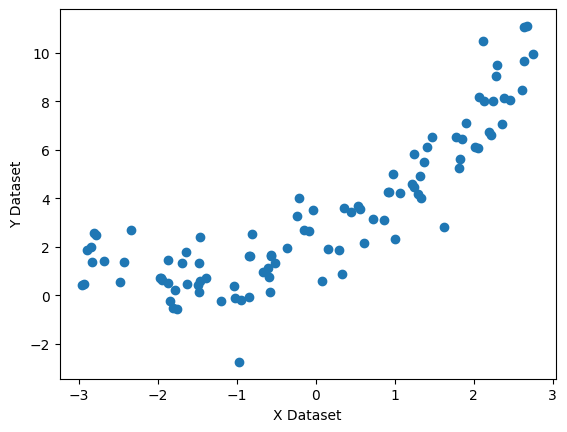

In [8]:
plt.scatter(X,y)
plt.xlabel('X Dataset')
plt.ylabel('Y Dataset')

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [10]:
# Implement simple linear regression for comparision
from sklearn.linear_model import LinearRegression
Lregression=LinearRegression()

In [11]:
X_train
y_train

array([[ 6.07854078],
       [ 4.47836648],
       [ 0.70475452],
       [ 8.15772476],
       [-0.23839754],
       [ 1.34295599],
       [ 1.91737636],
       [ 3.59644827],
       [ 6.50847531],
       [ 2.55165476],
       [ 0.131617  ],
       [ 6.50312231],
       [ 3.09927621],
       [ 0.71737344],
       [-2.75424453],
       [ 0.51233542],
       [ 2.47613845],
       [ 6.71517947],
       [-0.09219743],
       [ 0.21970412],
       [ 7.99471798],
       [ 5.25282129],
       [ 2.41097574],
       [ 4.60149485],
       [ 4.91513562],
       [ 3.277866  ],
       [ 5.48260044],
       [-0.11642195],
       [ 2.00517175],
       [ 1.85318169],
       [ 1.6255677 ],
       [-0.19190127],
       [ 3.65930204],
       [ 0.44179204],
       [-0.52154909],
       [ 7.99017122],
       [ 7.08592835],
       [ 1.63171737],
       [ 0.43325361],
       [ 2.70516365],
       [-0.25311718],
       [ 1.12644725],
       [ 3.55398279],
       [ 1.44932407],
       [ 9.63909532],
       [ 0

Both are in basic scale so no need for scaling

In [12]:
Lregression.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
from sklearn.metrics import r2_score
score=r2_score(y_test,Lregression.predict(X_test))

In [14]:
score

0.7180359927418488

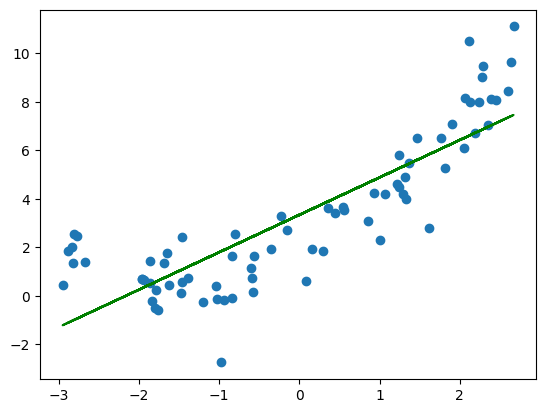

In [15]:
##Visualise
plt.scatter(X_train,y_train)
plt.plot(X_train,Lregression.predict(X_train),'g')

QUite a lot of error

Time to try another method:-

## Polynomial Regression


In [16]:
## Apply Polynomial Transformation

from sklearn.preprocessing import PolynomialFeatures ## Used to increase degree



In [17]:
poly=PolynomialFeatures(degree=2,include_bias=True) ## bias adds another column of ones which can act as the coefficient of the intercepts so that intercepts are taken into account and not just treated as zeroes

In [18]:
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)

In [19]:
X_train_poly

array([[ 1.00000000e+00,  2.05469404e+00,  4.22176758e+00],
       [ 1.00000000e+00,  1.23767127e+00,  1.53183016e+00],
       [ 1.00000000e+00, -1.96298171e+00,  3.85329720e+00],
       [ 1.00000000e+00,  2.06830490e+00,  4.27788515e+00],
       [ 1.00000000e+00, -1.84520143e+00,  3.40476832e+00],
       [ 1.00000000e+00, -1.69325027e+00,  2.86709646e+00],
       [ 1.00000000e+00,  1.52146466e-01,  2.31485472e-02],
       [ 1.00000000e+00,  3.54717718e-01,  1.25824660e-01],
       [ 1.00000000e+00,  1.77176831e+00,  3.13916296e+00],
       [ 1.00000000e+00, -2.80839408e+00,  7.88707728e+00],
       [ 1.00000000e+00, -1.48207605e+00,  2.19654941e+00],
       [ 1.00000000e+00,  1.47348090e+00,  2.17114595e+00],
       [ 1.00000000e+00,  8.59733909e-01,  7.39142394e-01],
       [ 1.00000000e+00, -1.39393758e+00,  1.94306198e+00],
       [ 1.00000000e+00, -9.75838107e-01,  9.52260012e-01],
       [ 1.00000000e+00, -1.86365598e+00,  3.47321362e+00],
       [ 1.00000000e+00, -2.78193623e+00

The format is [1, x, x^2]

In [20]:
X_test_poly

array([[ 1.00000000e+00, -2.15646502e-01,  4.65034138e-02],
       [ 1.00000000e+00,  2.75114278e+00,  7.56878659e+00],
       [ 1.00000000e+00,  1.84548937e+00,  3.40583103e+00],
       [ 1.00000000e+00, -2.93013058e+00,  8.58566524e+00],
       [ 1.00000000e+00, -5.15224392e-01,  2.65456174e-01],
       [ 1.00000000e+00,  9.19487400e-01,  8.45457079e-01],
       [ 1.00000000e+00,  2.63373974e+00,  6.93658502e+00],
       [ 1.00000000e+00, -2.47398722e+00,  6.12061278e+00],
       [ 1.00000000e+00, -2.34259415e+00,  5.48774734e+00],
       [ 1.00000000e+00, -2.43167790e+00,  5.91305740e+00],
       [ 1.00000000e+00,  6.14074238e-01,  3.77087170e-01],
       [ 1.00000000e+00, -8.28637973e-01,  6.86640890e-01],
       [ 1.00000000e+00,  3.27299889e-01,  1.07125218e-01],
       [ 1.00000000e+00, -5.65601278e-01,  3.19904806e-01],
       [ 1.00000000e+00,  1.83180743e+00,  3.35551845e+00],
       [ 1.00000000e+00, -2.81893605e-02,  7.94640046e-04],
       [ 1.00000000e+00, -1.48030268e+00

In [21]:
from sklearn.metrics import r2_score
regression=LinearRegression()
regression.fit(X_train_poly,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [22]:
y_pred=regression.predict(X_test_poly)

In [23]:
y_pred

array([[ 1.44828767],
       [10.1954906 ],
       [ 6.52849425],
       [ 1.68007357],
       [ 1.08754939],
       [ 3.68482129],
       [ 9.67070762],
       [ 1.09104313],
       [ 0.96259498],
       [ 1.04766943],
       [ 2.94775332],
       [ 0.8127415 ],
       [ 2.34635226],
       [ 1.0363019 ],
       [ 6.47981268],
       [ 1.7227678 ],
       [ 0.57718002],
       [ 7.91691602],
       [ 5.06361401],
       [ 3.82853648],
       [ 3.21787299],
       [ 1.6415074 ],
       [ 0.57709488],
       [ 7.1502451 ],
       [ 0.94305709]])

In [24]:
score=r2_score(y_test,y_pred)
print(score)

0.8593280990393891


HUGE improvement

In [25]:
print(regression.coef_)

[[0.         1.59443541 0.53399333]]


Here we can see 3 coefficients because of bias

In [26]:
print(regression.intercept_)

[1.76728958]


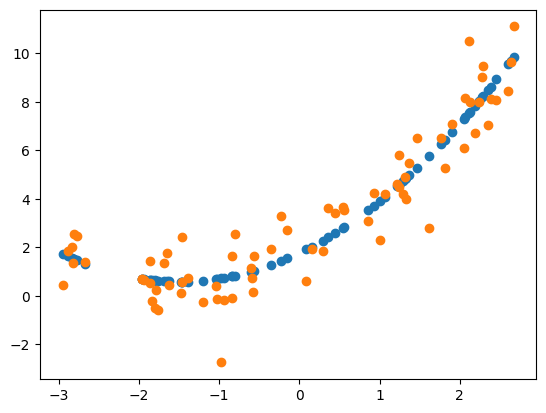

In [27]:
plt.scatter(X_train,regression.predict(X_train_poly))
plt.scatter(X_train,y_train)

This is the best fit line 


Now let's check for higher degrees

In [28]:
poly=PolynomialFeatures(degree=3,include_bias=True)
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)

In [29]:
X_train_poly

array([[ 1.00000000e+00,  2.05469404e+00,  4.22176758e+00,
         8.67444068e+00],
       [ 1.00000000e+00,  1.23767127e+00,  1.53183016e+00,
         1.89590218e+00],
       [ 1.00000000e+00, -1.96298171e+00,  3.85329720e+00,
        -7.56395194e+00],
       [ 1.00000000e+00,  2.06830490e+00,  4.27788515e+00,
         8.84797082e+00],
       [ 1.00000000e+00, -1.84520143e+00,  3.40476832e+00,
        -6.28248338e+00],
       [ 1.00000000e+00, -1.69325027e+00,  2.86709646e+00,
        -4.85471185e+00],
       [ 1.00000000e+00,  1.52146466e-01,  2.31485472e-02,
         3.52196965e-03],
       [ 1.00000000e+00,  3.54717718e-01,  1.25824660e-01,
         4.46322361e-02],
       [ 1.00000000e+00,  1.77176831e+00,  3.13916296e+00,
         5.56186946e+00],
       [ 1.00000000e+00, -2.80839408e+00,  7.88707728e+00,
        -2.21500211e+01],
       [ 1.00000000e+00, -1.48207605e+00,  2.19654941e+00,
        -3.25545327e+00],
       [ 1.00000000e+00,  1.47348090e+00,  2.17114595e+00,
      

4 features now.
Let's check accuracy

In [30]:
from sklearn.metrics import r2_score
regression=LinearRegression()
regression.fit(X_train_poly,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [31]:
y_pred=regression.predict(X_test_poly)
score=r2_score(y_test,y_pred)
print(score)

0.8555393750933302


Almost same as degree=2. Extremely minute difference in this case

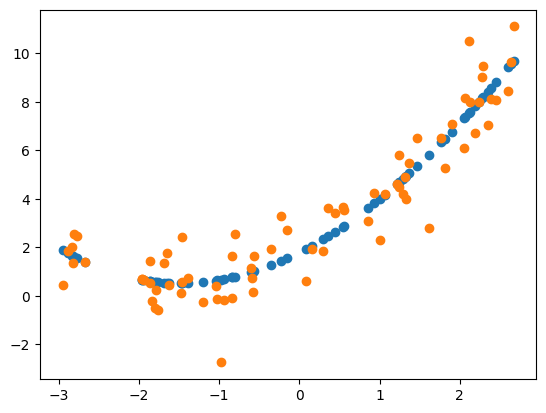

In [32]:
plt.scatter(X_train,regression.predict(X_train_poly))
plt.scatter(X_train,y_train)

In [33]:
# Prediction of new data set
X_new=np.linspace(-3,3,200).reshape(200,1)
X_new_poly=poly.transform(X_new)
X_new_poly

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00,
        -2.70000000e+01],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00,
        -2.61940839e+01],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00,
        -2.54043665e+01],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00,
        -2.46306834e+01],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00,
        -2.38728702e+01],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00,
        -2.31307624e+01],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00,
        -2.24041955e+01],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00,
        -2.16930052e+01],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00,
        -2.09970269e+01],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00,
        -2.03160961e+01],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00,
        -1.96500486e+01],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00,
      

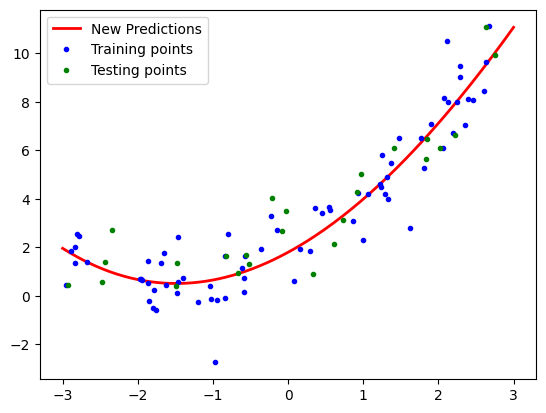

In [34]:
y_new=regression.predict(X_new_poly)
plt.plot(X_new,y_new,"r-",linewidth=2,label="New Predictions")
plt.plot(X_train,y_train,"b.",label='Training points')
plt.plot(X_test,y_test,"g.", label="Testing points")
plt.legend()
plt.show()

## Pipeline

In [35]:
from sklearn.pipeline import Pipeline

In [61]:
def poly_regression(degree):
    X_new=np.linspace(-3,3,200).reshape(200,1)
    poly_features=PolynomialFeatures(degree=degree,include_bias=True)
    lin_reg=LinearRegression()
    poly_regression=Pipeline([
        ("poly_features",poly_features),
        ("lin_reg",lin_reg)
    ])
    poly_regression.fit(X_train,y_train)
    y_pred_new=poly_regression.predict(X_new)
    # Plot prediction line
    plt.plot(X_new,y_pred_new,'r',label="Degree "+str(degree),linewidth=3)
    plt.plot(X_train,y_train,'b.',linewidth=3)
    plt.plot(X_test,y_test,"g.",linewidth=3)
    plt.legend(loc="upper left")
    plt.axis([-4,4,0,12])
    plt.show()

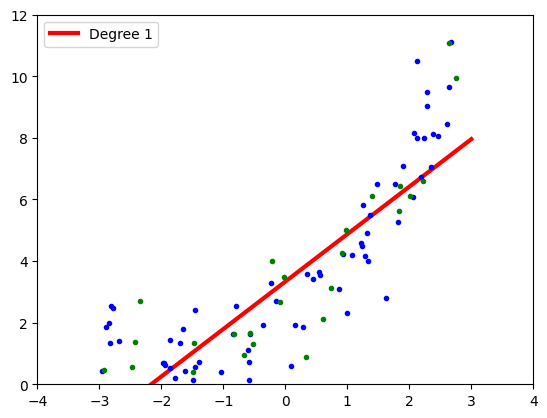

In [62]:
poly_regression(1)

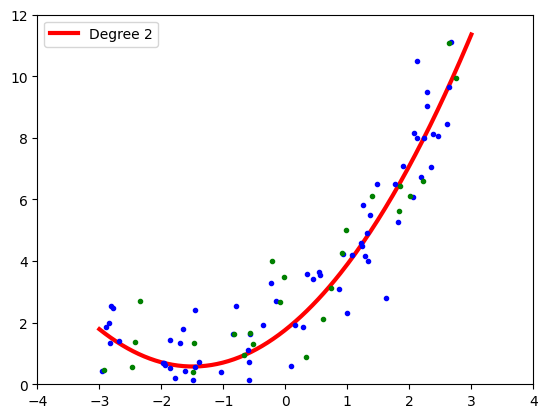

In [63]:
poly_regression(2)

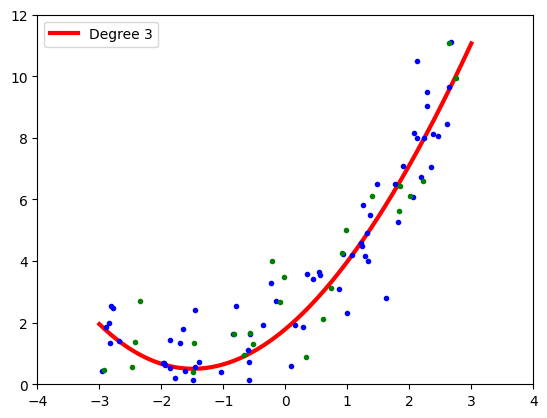

In [64]:
poly_regression(3)

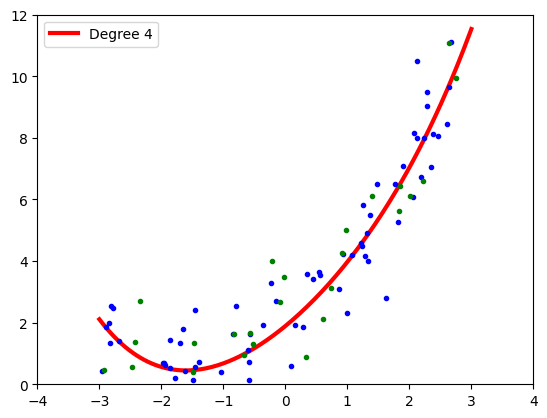

In [65]:

poly_regression(4)

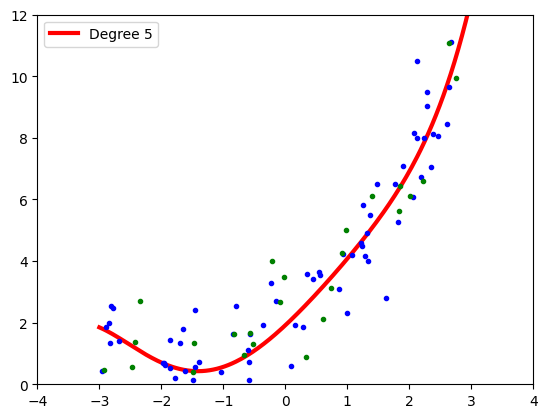

In [66]:

poly_regression(5)

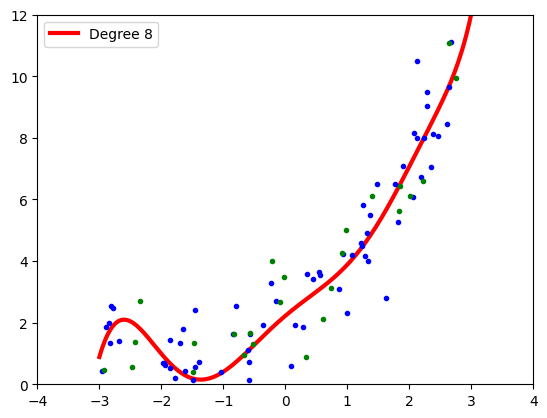

In [67]:
poly_regression(8)

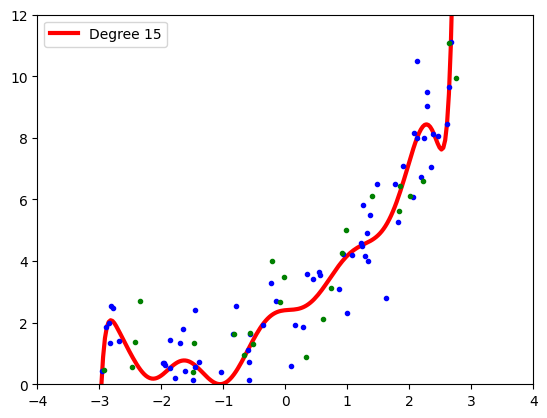

In [68]:

poly_regression(15)

As degree increased, it gradually started overfitting
